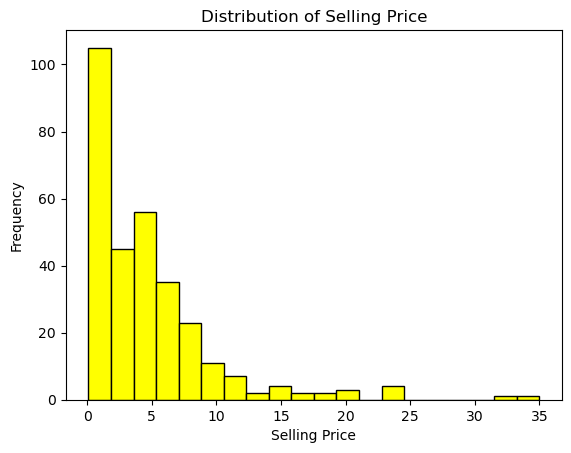

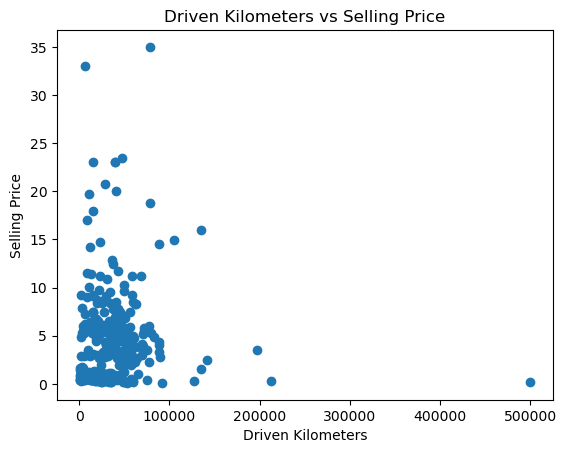

<Figure size 640x480 with 0 Axes>

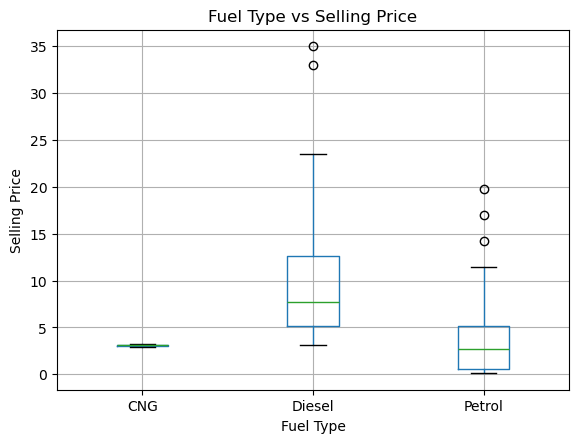

<Figure size 640x480 with 0 Axes>

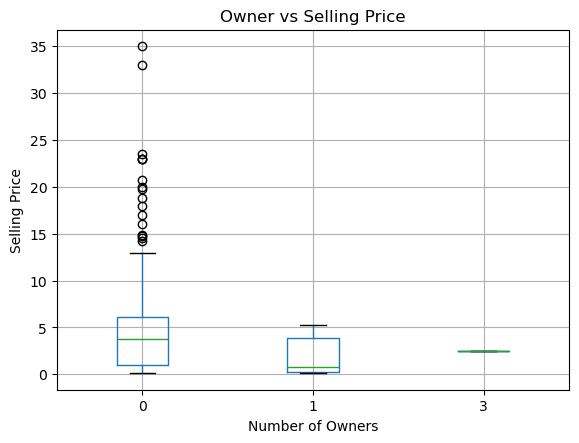

MAE: 0.6171180327868853
MSE: 0.851238144918032
R² Score: 0.963046818101436


In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
df=pd.read_csv('Car Data.csv')
#print(df)
df.isnull().sum()
df.describe()
#EXPLORATORY DATA ANALYSIS
#📈 Selling_Price Distribution (Histogram)
plt.figure()
plt.hist(df['Selling_Price'], bins=20,color='yellow',edgecolor='black')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Selling Price')
plt.show()
#🔹 3️⃣ Driven_kms vs Selling_Price
#📉 Scatter Plot
plt.figure()
plt.scatter(df['Driven_kms'], df['Selling_Price'])
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')
plt.title('Driven Kilometers vs Selling Price')
plt.show()
#🔹 5️⃣ Fuel_Type vs Selling_Price
#📊 Box Plot
plt.figure()
df.boxplot(column='Selling_Price', by='Fuel_Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.title('Fuel Type vs Selling Price')
plt.suptitle('')   # removes default extra title
plt.show()
#🔹 8️⃣ Owner vs Selling_Price
#📊 Box Plot
plt.figure()
df.boxplot(column='Selling_Price', by='Owner')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price')
plt.title('Owner vs Selling Price')
plt.suptitle('')
plt.show()
#Doing encoding(to deal with categorical variables)
categorical_columns=['Fuel_Type','Selling_type','Transmission']
for column in categorical_columns:
    le=LabelEncoder()
    df[column] = le.fit_transform(df[column])

#Feature scaling of numeric columns
num_col=['Driven_kms','Present_Price']
Scaler=StandardScaler()
df[num_col]=Scaler.fit_transform(df[num_col])

df = df.drop('Car_Name', axis=1)#dropping one column

#Separating features & target
X=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#model training
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)
#----make predictions------
y_pred = rf_model.predict(X_test)
#Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)